In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import zipfile
from scipy import stats

In [2]:
zip_file_path = "C:\\Users\\PC\\Documents\\UoM\\BMAN73701 - Python\\Coursework\\Products_Information.zip"

In [3]:
extracted_dir = 'C:\\Users\\PC\\Documents\\UoM\\BMAN73701 - Python\\Coursework'

In [4]:
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    # Extract all contents to the specified directory
    zip_ref.extractall(extracted_dir)

In [5]:
file = "Products_Information.csv"

In [6]:
#1.1. Load the data
data = pd.read_csv(file)
data.head(-10)

,id,date,store_nbr,product_type,sales,special_offer
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0
1,1,2013-01-01,1,BABY CARE,0.0,0
2,2,2013-01-01,1,BEAUTY,0.0,0
3,3,2013-01-01,1,BEVERAGES,0.0,0
4,4,2013-01-01,1,BOOKS,0.0,0
...,...,...,...,...,...,...
3000873,3000873,2017-08-15,9,HOME CARE,373.0,6
3000874,3000874,2017-08-15,9,LADIESWEAR,10.0,0
3000875,3000875,2017-08-15,9,LAWN AND GARDEN,11.0,3
3000876,3000876,2017-08-15,9,LINGERIE,6.0,0


In [7]:
#1.2. Exlore the data
data.info()
data.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000888 entries, 0 to 3000887
Data columns (total 6 columns):
 #   Column         Dtype  
---  ------         -----  
 0   id             int64  
 1   date           object 
 2   store_nbr      int64  
 3   product_type   object 
 4   sales          float64
 5   special_offer  int64  
dtypes: float64(1), int64(3), object(2)
memory usage: 137.4+ MB


,id,store_nbr,sales,special_offer
count,3.000888e+06,3.000888e+06,3.000888e+06,3.000888e+06
mean,1.500444e+06,2.750000e+01,3.577757e+02,2.602770e+00
std,8.662819e+05,1.558579e+01,1.101998e+03,1.221888e+01
min,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00
25%,7.502218e+05,1.400000e+01,0.000000e+00,0.000000e+00
50%,1.500444e+06,2.750000e+01,1.100000e+01,0.000000e+00
75%,2.250665e+06,4.100000e+01,1.958473e+02,0.000000e+00
max,3.000887e+06,5.400000e+01,1.247170e+05,7.410000e+02


In [8]:
#1.3. Observe the products and stores that need to be forecasted
unique_products = data['product_type'].unique()
print(unique_products)
unique_stores = data['store_nbr'].unique()
print(unique_stores)

['AUTOMOTIVE' 'BABY CARE' 'BEAUTY' 'BEVERAGES' 'BOOKS' 'BREAD/BAKERY'
 'CELEBRATION' 'CLEANING' 'DAIRY' 'DELI' 'EGGS' 'FROZEN FOODS' 'GROCERY I'
 'GROCERY II' 'HARDWARE' 'HOME AND KITCHEN I' 'HOME AND KITCHEN II'
 'HOME APPLIANCES' 'HOME CARE' 'LADIESWEAR' 'LAWN AND GARDEN' 'LINGERIE'
 'LIQUOR,WINE,BEER' 'MAGAZINES' 'MEATS' 'PERSONAL CARE' 'PET SUPPLIES'
 'PLAYERS AND ELECTRONICS' 'POULTRY' 'PREPARED FOODS' 'PRODUCE'
 'SCHOOL AND OFFICE SUPPLIES' 'SEAFOOD']
[ 1 10 11 12 13 14 15 16 17 18 19  2 20 21 22 23 24 25 26 27 28 29  3 30
 31 32 33 34 35 36 37 38 39  4 40 41 42 43 44 45 46 47 48 49  5 50 51 52
 53 54  6  7  8  9]


In [9]:
#1.4. Check for missing values
print("Number of missing values:\n", data.isnull().sum())

# Handle missing values (e.g., forward fill, backward fill, interpolation)
data['sales'].fillna(method='ffill', inplace=True)

Number of missing values:
 id               0
date             0
store_nbr        0
product_type     0
sales            0
special_offer    0
dtype: int64


In [10]:
#1.5 Extract the data for 2016 for training purpose
data.index = pd.to_datetime(data['date'])
data['date'] = pd.to_datetime(data['date'])

data_train = data.loc['2016',].copy()
data_train

,id,date,store_nbr,product_type,sales,special_offer
date,,,,,,
2016-01-01,1945944,2016-01-01,1,AUTOMOTIVE,0.000,0
2016-01-01,1945945,2016-01-01,1,BABY CARE,0.000,0
2016-01-01,1945946,2016-01-01,1,BEAUTY,0.000,0
2016-01-01,1945947,2016-01-01,1,BEVERAGES,0.000,0
2016-01-01,1945948,2016-01-01,1,BOOKS,0.000,0
...,...,...,...,...,...,...
2016-12-31,2596369,2016-12-31,9,POULTRY,687.853,1
2016-12-31,2596370,2016-12-31,9,PREPARED FOODS,100.405,1
2016-12-31,2596371,2016-12-31,9,PRODUCE,3091.356,3


In [11]:
#1.6. Extract data for testing purpose
start_date = '2017-07-17'
end_date = '2017-08-15'
data_test =  data[(data['date'] >= start_date) & (data['date'] <= end_date)]
data_test

,id,date,store_nbr,product_type,sales,special_offer
date,,,,,,
2017-07-17,2947428,2017-07-17,1,AUTOMOTIVE,2.000,0
2017-07-17,2947429,2017-07-17,1,BABY CARE,0.000,0
2017-07-17,2947430,2017-07-17,1,BEAUTY,5.000,0
2017-07-17,2947431,2017-07-17,1,BEVERAGES,2381.000,39
2017-07-17,2947432,2017-07-17,1,BOOKS,1.000,0
...,...,...,...,...,...,...
2017-08-15,3000883,2017-08-15,9,POULTRY,438.133,0
2017-08-15,3000884,2017-08-15,9,PREPARED FOODS,154.553,1
2017-08-15,3000885,2017-08-15,9,PRODUCE,2419.729,148


In [12]:
#1.7. Check for outliers

# Determine z-score for sales data
z_scores = stats.zscore(data_train['sales'])
threshold = 3

# Identify outliers
outliers = (np.abs(z_scores) > threshold)

# Display or filter outliers
print(data_train[outliers])

                 id       date  store_nbr product_type      sales  \
date                                                                
2016-01-01  1946508 2016-01-01         25    BEVERAGES   5104.000   
2016-01-02  1947795 2016-01-02         11    BEVERAGES   8238.000   
2016-01-02  1947804 2016-01-02         11    GROCERY I  10279.158   
2016-01-02  1947870 2016-01-02         13    GROCERY I   5488.000   
2016-01-02  1947903 2016-01-02         14    GROCERY I   4354.000   
...             ...        ...        ...          ...        ...   
2016-12-31  2596311 2016-12-31          8    BEVERAGES   5596.000   
2016-12-31  2596320 2016-12-31          8    GROCERY I   5317.000   
2016-12-31  2596338 2016-12-31          8      PRODUCE   5993.142   
2016-12-31  2596344 2016-12-31          9    BEVERAGES   4435.000   
2016-12-31  2596353 2016-12-31          9    GROCERY I   7657.226   

            special_offer  
date                       
2016-01-01              1  
2016-01-02        

In [13]:
#Extract data for only automotive
automotive_train = data_train[data_train['product_type'] == "AUTOMOTIVE"]
automotive_train

,id,date,store_nbr,product_type,sales,special_offer
date,,,,,,
2016-01-01,1945944,2016-01-01,1,AUTOMOTIVE,0.0,0
2016-01-01,1945977,2016-01-01,10,AUTOMOTIVE,0.0,0
2016-01-01,1946010,2016-01-01,11,AUTOMOTIVE,0.0,0
2016-01-01,1946043,2016-01-01,12,AUTOMOTIVE,0.0,0
2016-01-01,1946076,2016-01-01,13,AUTOMOTIVE,0.0,0
...,...,...,...,...,...,...
2016-12-31,2596209,2016-12-31,54,AUTOMOTIVE,18.0,0
2016-12-31,2596242,2016-12-31,6,AUTOMOTIVE,6.0,0
2016-12-31,2596275,2016-12-31,7,AUTOMOTIVE,5.0,0


In [14]:
#1.8 Count the number of zero values in the 'sales' column
zero_count = (data_train['sales'] == 0).sum()
total_count = data_train['sales'].count()
print("Number of zero values in the 'sales' column:", zero_count, "\n Number of total values:", total_count, "\n Percentage:", zero_count/total_count*100, "%")

Number of zero values in the 'sales' column: 119922 
 Number of total values: 650430 
 Percentage: 18.437341451040083 %


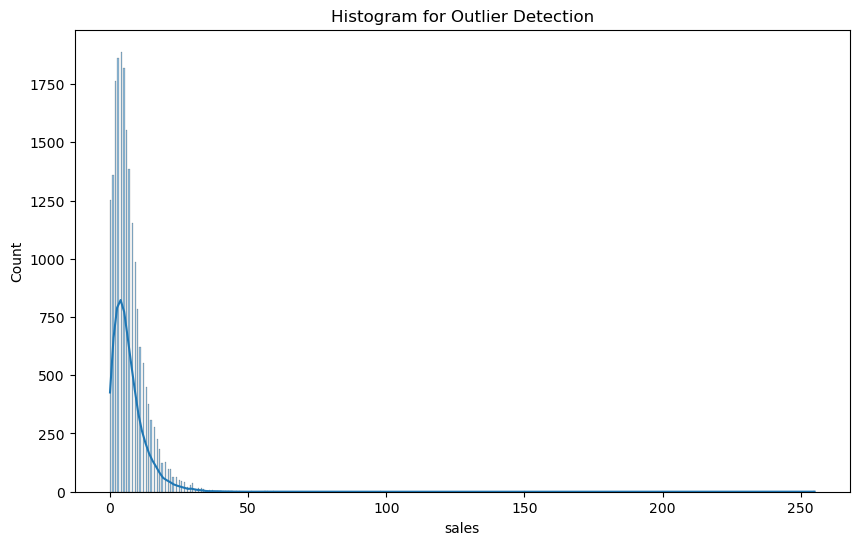

In [15]:
#Plot outliers for automotive
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(automotive_train['sales'], kde=True)
plt.title('Histogram for Outlier Detection')
plt.show()